# VeryCloudy — Basic Analysis

All plotting logic lives in `src/verycloudy/analysis.py`.  
This notebook only loads data, calls functions, and displays results.

**To switch between testset and full dataset:** change the import in cell 0 between  
`FILEPATH_FULL_TESTSET` (default, small) and `FILEPATH_FULL` (production).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from verycloudy.analysis import (
    summary_table,
    completeness_bar,
    rows_per_year,
    country_counts,
    top_countries_bar,
    world_choropleth,
    cloud_type_bar,
    subtype_bar,
    cooccurrence_heatmap,
    weather_histograms,
    boxplots_by_cloudtype,
    scatter_cape_vs_clouds,
    scatter_dew_spread_by_cloudtype,
    scatter_low_vs_high_cover,
    scatter_humidity_dew,
)
from verycloudy.styling import standard_style
from verycloudy.config import FILEPATH_FULL_TESTSET  # swap to FILEPATH_FULL for production

standard_style()

# Load the combined dataset (cloud rows + no-cloud rows merged into one file)
df = pd.read_csv(FILEPATH_FULL_TESTSET)
print(f"Loaded {len(df)} rows, {df.columns.tolist()}")

Loaded 1100 rows, ['lightbox_id', 'image_url', 'date_iso', 'date_raw', 'author_name', 'author_profile', 'title', 'tags', 'status', 'date_taken', 'time_taken', 'date_taken_utc_xmp', 'time_taken_utc_xmp', 'datetime_source', 'fallback_dt_used', 'datetime_capture', 'city', 'region', 'country', 'latitude', 'longitude', 'location_source', 'dt_unix', 'date_taken_utc_y', 'time_taken_utc_y', 'temp', 'feels_like', 'pressure', 'humidity', 'dew_point', 'clouds', 'clouds_low', 'clouds_mid', 'clouds_high', 'wind_speed', 'wind_deg', 'wind_gust', 'visibility', 'weather_code', 'rain_1h', 'snow_1h', 'uvi', 'cloud_type1', 'cloud_type2', 'cloud_type3', 'subtype1', 'subtype2', 'cloud_type_fix', 'source_field', 'fallback_used', 'error', 'date_taken_utc', 'time_taken_utc']


---
## 1. Dataset overview

In [3]:
display(summary_table(df))

,column,filled,missing,fill_pct
0,total rows,1100,0,100.0
1,date range,2005-03-23,,
2,date range end,2026-03-06,,
3,unique countries,93,,
4,latitude,1055,45,95.9
5,longitude,1055,45,95.9
6,date_taken,1100,0,100.0
7,time_taken,1100,0,100.0
8,temp,1055,45,95.9
9,clouds,1055,45,95.9


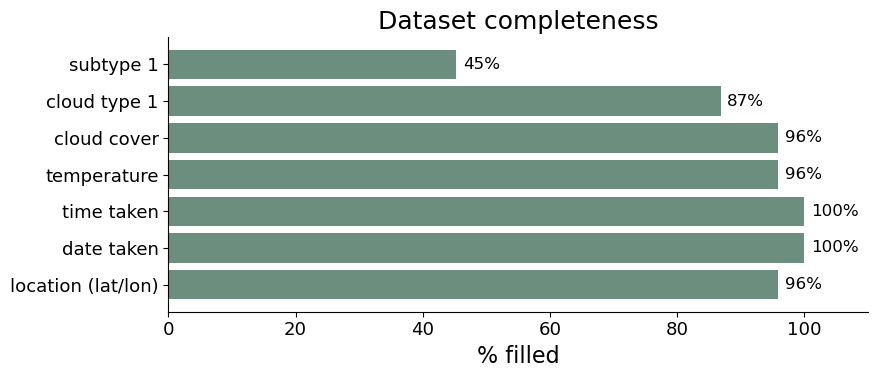

In [4]:
fig = completeness_bar(df)
plt.show()

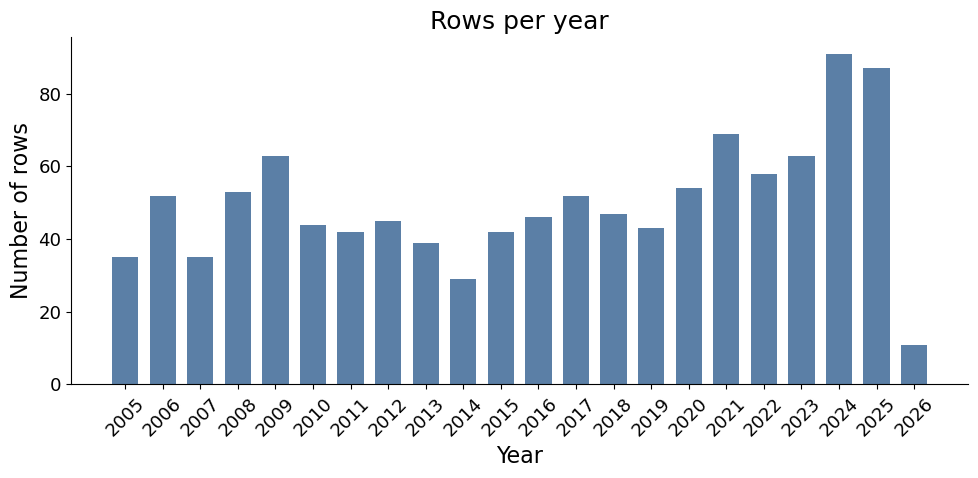

In [5]:
fig = rows_per_year(df)
plt.show()

---
## 2. Geographic spread

In [6]:
display(country_counts(df).head(20).rename('count').to_frame())

,count
country,
US,305
GB,193
United States,64
IT,51
AU,50
CA,28
FR,26
United Kingdom,25
ES,23


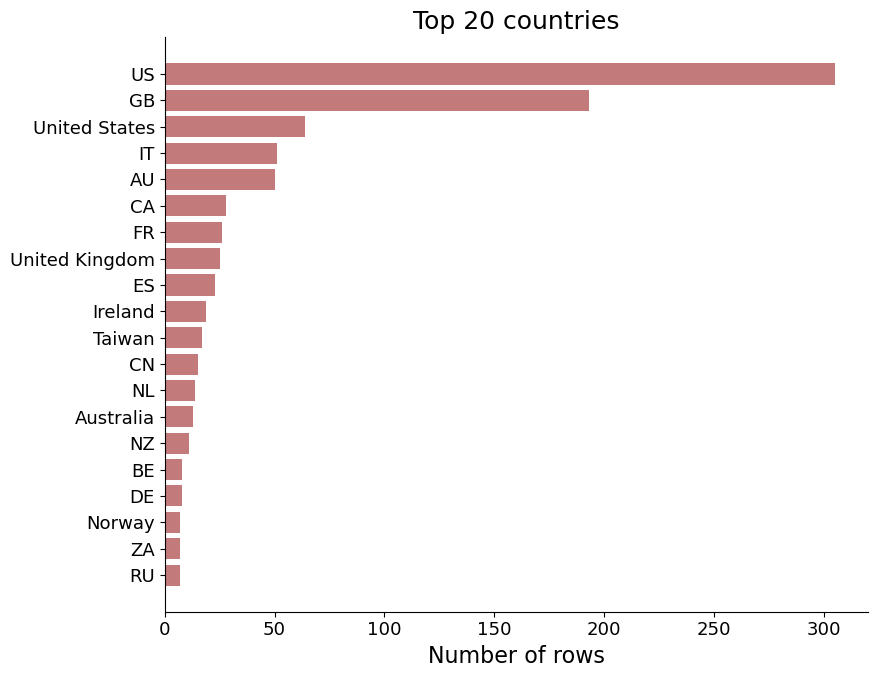

In [7]:
fig = top_countries_bar(df, n=20)
plt.show()

In [8]:
fig = world_choropleth(df)
fig.show()

---
## 3. Cloud types

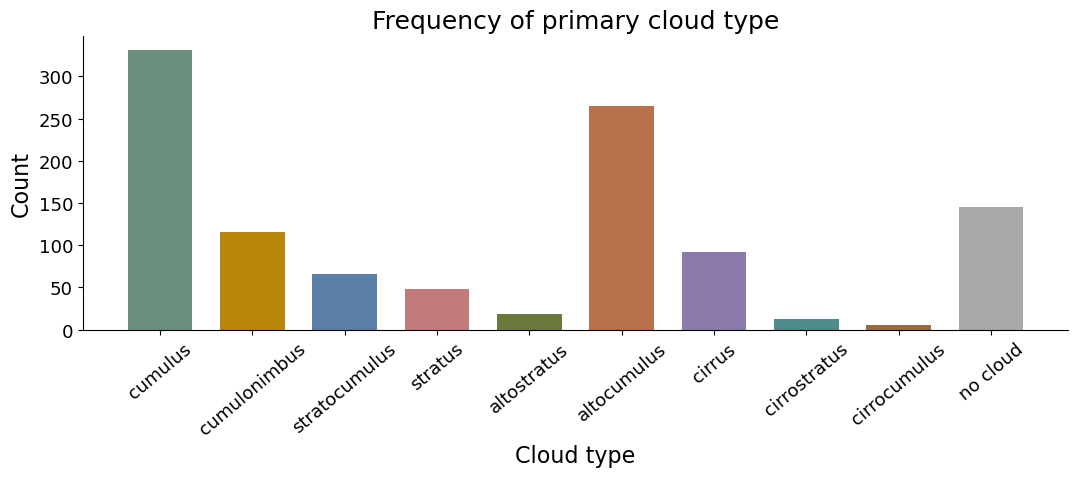

In [9]:
fig = cloud_type_bar(df)
plt.show()

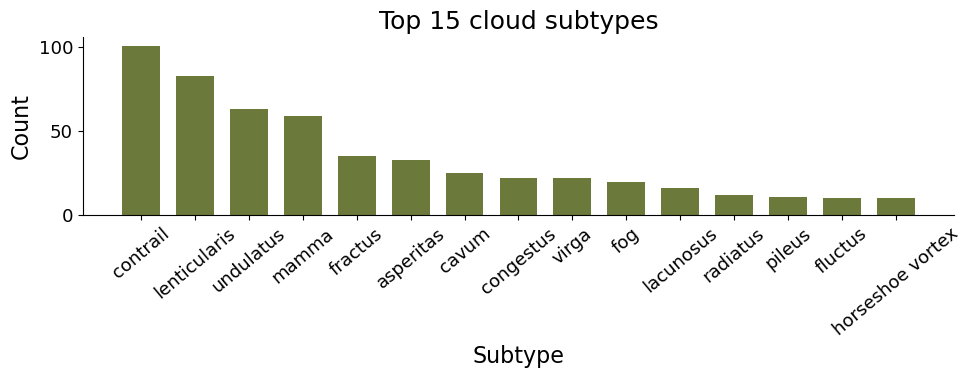

In [10]:
fig = subtype_bar(df, n=15)
plt.show()

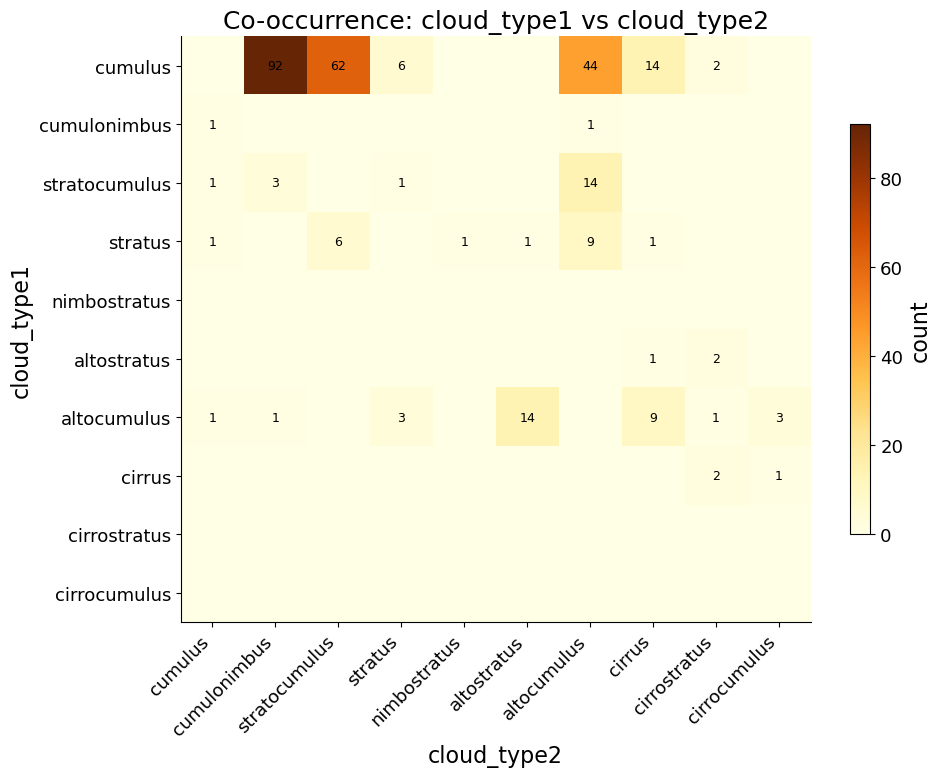

In [11]:
# Co-occurrence on cloudy rows only (rows that have a cloud_type1)
df_cloudy = df[df['cloud_type1'].notna()]
fig = cooccurrence_heatmap(df_cloudy)
plt.show()

---
## 4. Weather distributions

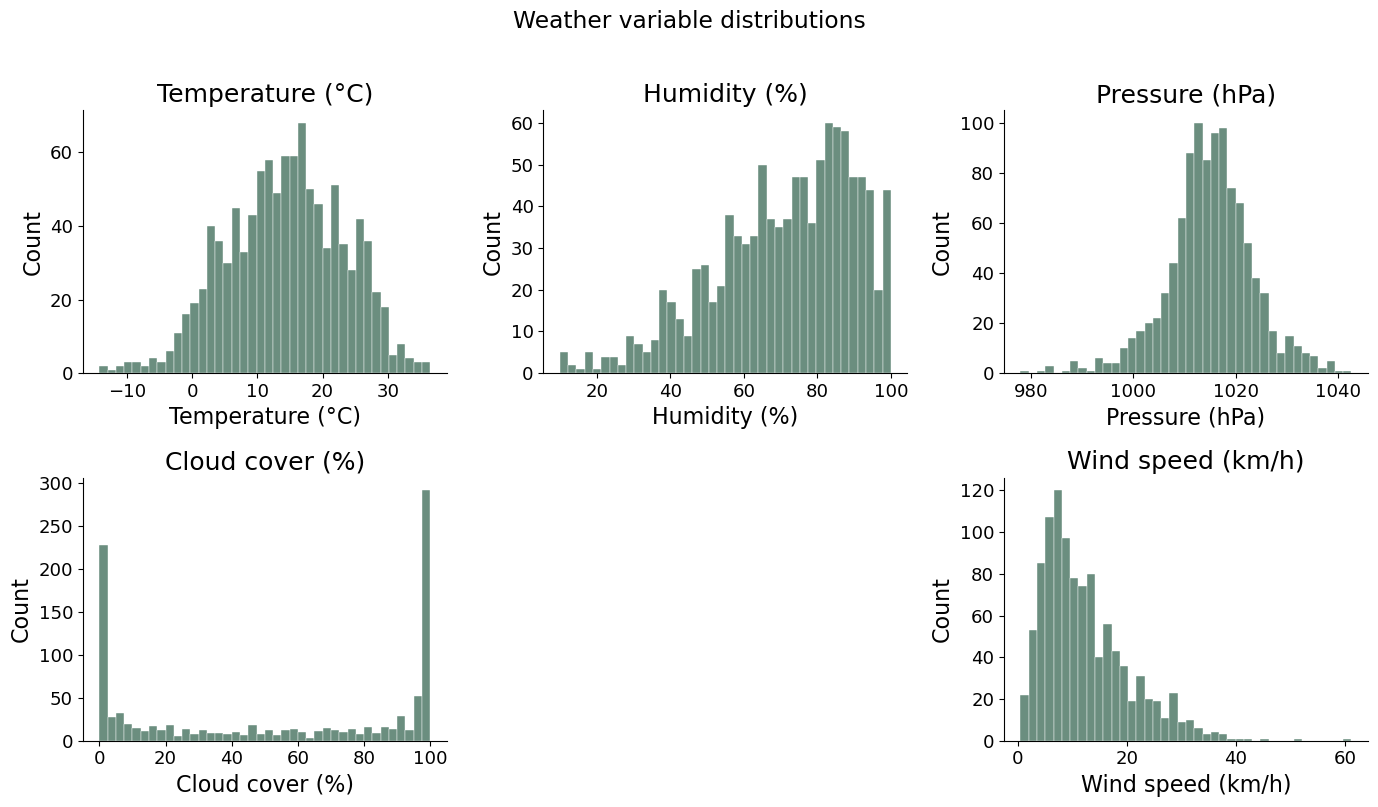

In [12]:
fig = weather_histograms(df)
plt.show()

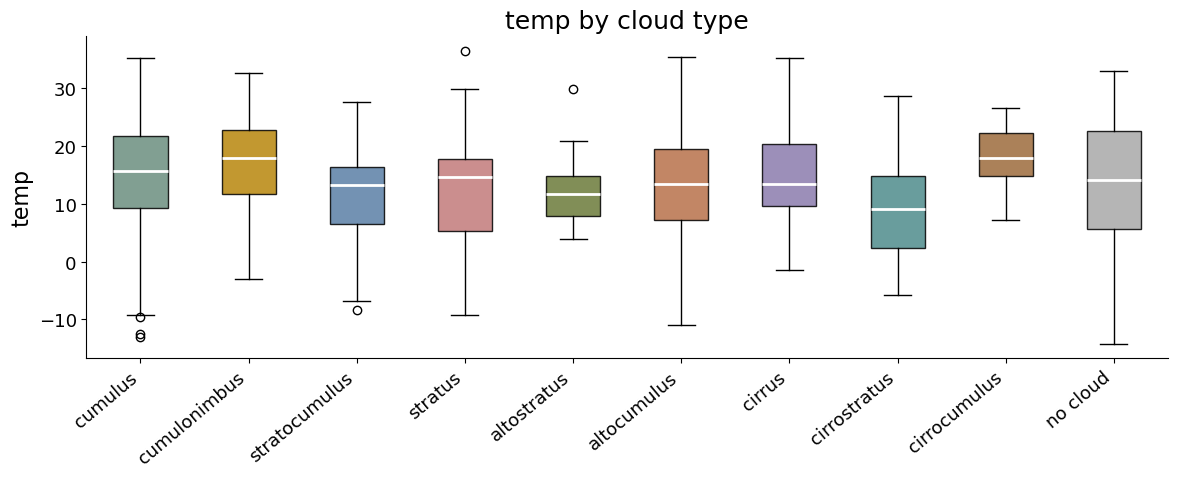

In [13]:
fig = boxplots_by_cloudtype(df, 'temp')
plt.show()

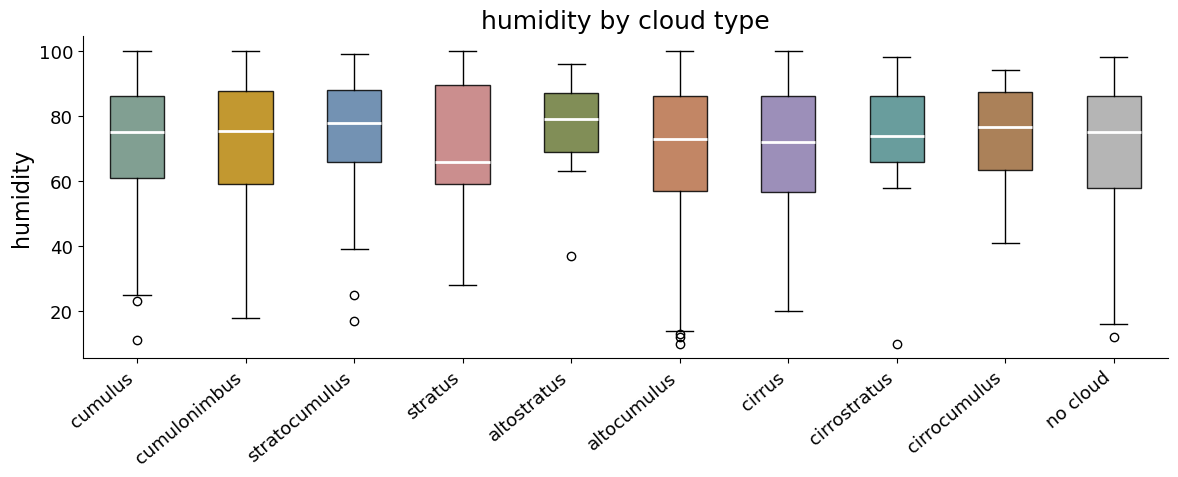

In [14]:
fig = boxplots_by_cloudtype(df, 'humidity')
plt.show()

---
## 5. Cloud type vs weather

These charts are designed to show the meteorological signal behind each cloud type —
useful for the oral exam and as motivation for the ML model features.

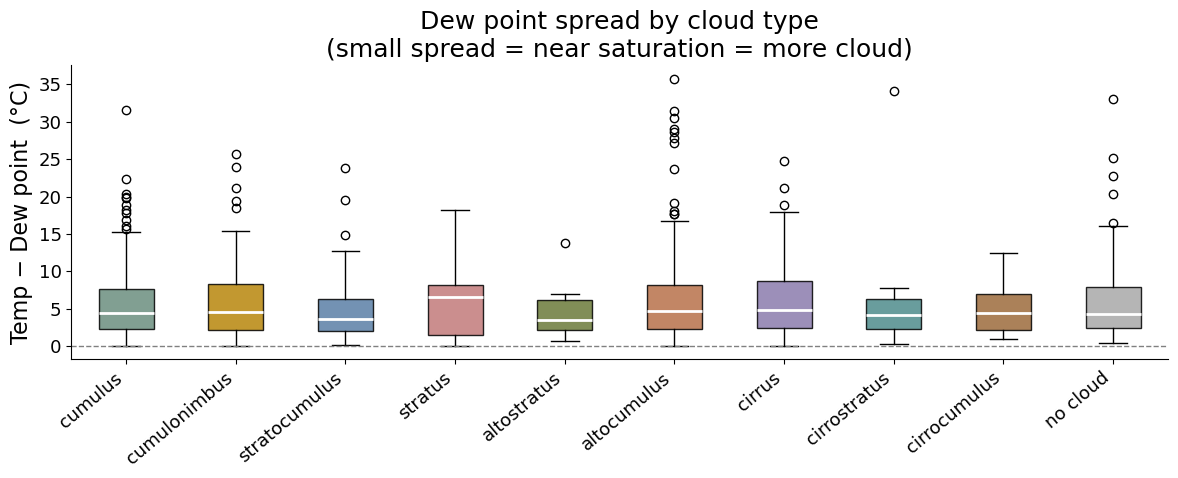

In [17]:
# Dew point spread (temp - dew_point) by cloud type — low spread = humid/stratiform, high = dry/convective
fig = scatter_dew_spread_by_cloudtype(df)
plt.show()

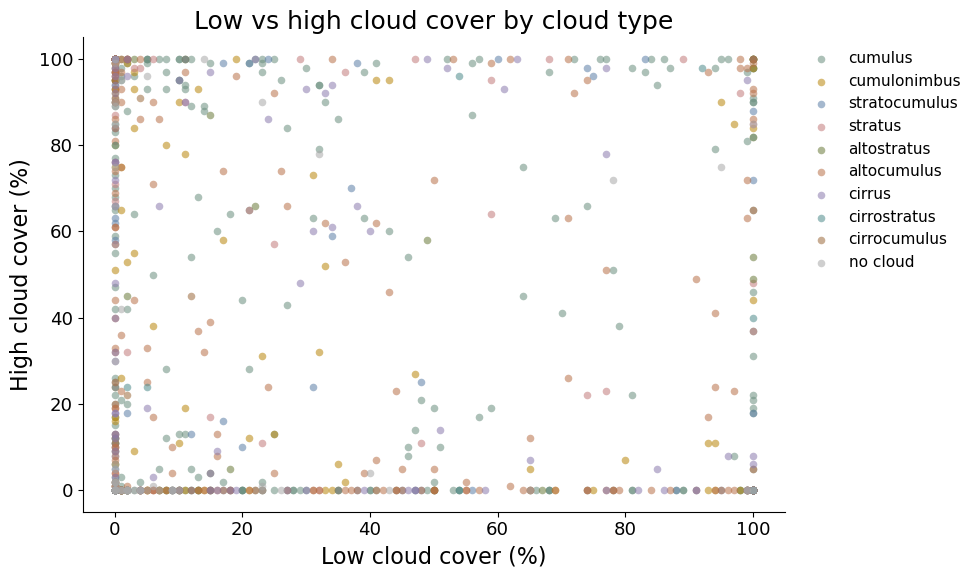

In [18]:
# Low vs high cloud cover — cloud family separation
fig = scatter_low_vs_high_cover(df)
plt.show()

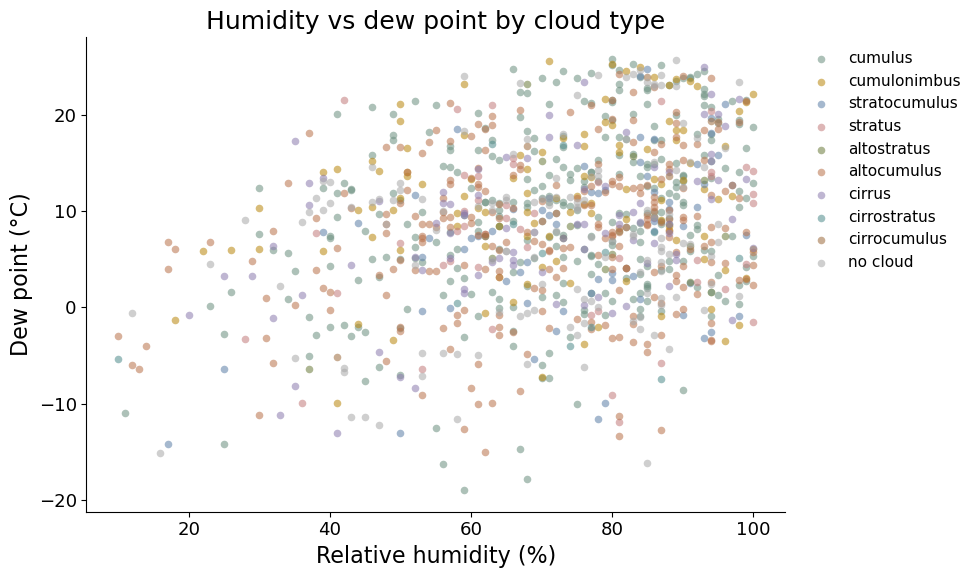

In [19]:
# Humidity vs dew point — stratiform clouds cluster at high humidity
fig = scatter_humidity_dew(df)
plt.show()